# QMSSGR5074 - Project 3


### Your Group ID: 3-4
### Your UNIs: AS 7429, soo2117, xy2723
### Your Full Names: Adeline Setiawan, Stanley Omondi, Xuejing Yan (Carol)
### Public GitHub Repo: [Fill Here]

## DELETE THIS
**Team workflow:** develop in separate notebooks/scripts, then consolidate final results here.

Recommended owner sections:
- Person 1: Data, preprocessing, EDA
- Person 2: Classical ML baselines
- Person 3: Neural models + tuning
- All: Final comparison, error analysis, recommendation

## Description

## Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - Acquire the Stanford Sentiment Treebank dataset.  
   - Split into training, validation and test sets with stratified sampling to preserve class balance.  
   - Clearly document your splitting strategy and resulting dataset sizes.

2. **Text Cleaning & Tokenization**  
   - Implement a reusable preprocessing pipeline that handles at least:  
     - HTML removal, lowercasing, punctuation stripping  
     - Vocabulary pruning (e.g., rare words threshold)  
     - Tokenization (character- or word-level)  
   - Expose this as a function/class so it can be saved and re-loaded for inference.

3. **Feature Extraction**  
   - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
   - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
   - Save each preprocessor (vectorizer/tokenizer) to disk.

---

## Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - Visualize the number of positive vs. negative reviews.  
   - Compute descriptive statistics on review lengths (mean, median, IQR).  

2. **Text Characteristics**  
   - Plot the 20 most frequent tokens per sentiment class.  
   - Generate word clouds (or bar charts) highlighting key terms for each class.  

3. **Correlation Analysis**  
   - Analyze whether review length correlates with sentiment.  
   - Present findings numerically and with at least one visualization.

---

## Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Train at least two linear models on your TF-IDF features (e.g., logistic regression, linear SVM).  
   - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.  

2. **Random Forest & Gradient Boosting**  
   - Train two tree-based models (e.g., Random Forest, XGBoost) on the same features.  
   - Report feature-importance for each and discuss any notable tokens.

3. **Evaluation Metrics**  
   - Compute accuracy, precision, recall, F1-score, and ROC-AUC on the **held-out test set**.  
   - Present all results in a single comparison table.

---

## Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Build an embedding layer + a dense MLP classifier.  
   - Ensure you freeze vs. unfreeze embeddings in separate runs.

2. **Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.

3. **Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

---

## Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - Retrain one network using pre-trained GloVe (or FastText) embeddings.  
   - Compare results against your from-scratch embedding runs.

2. **Transformer Fine-Tuning**  
   - Fine-tune a BERT-family model on the training data.  
   - Clearly outline your training hyperparameters (learning rate, batch size, epochs).


---

## Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.  
   - Describe your search space and stopping criteria.

2. **Results Analysis**  
   - Report the best hyperparameter configuration found.  
   - Plot validation-loss (or metric) vs. trials to illustrate tuning behavior.

---

## Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - Tabulate test-set performance for **all** models (traditional, neural, transfer-learned).  
   - Highlight top‐performing model overall and top in each category.

2. **Statistical Significance**  
   - Perform a significance test (e.g., McNemar’s test) between your best two models.  

3. **Error Analysis**  
   - Identify at least 20 examples your best model misclassified.  
   - For a sample of 5, provide the raw text, predicted vs. true label, and a short discussion of each error—what linguistic artifact might have confused the model?

---

## Part 8 – Optional Challenge Extensions

- Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.  
- Integrate a sentiment lexicon feature (e.g., VADER scores) into your models and assess whether it improves predictions.  
- Deploy your best model as a simple REST API using Flask or FastAPI and demo it on a handful of user‐submitted reviews.

---

## Part 1 – Data Ingestion & Preprocessing


1. **Data Loading**  
    - Acquire the Stanford Sentiment Treebank dataset.
    - Split into training, validation, and test sets with stratified sampling to preserve class balance.
    - Clearly document your splitting strategy and resulting dataset sizes.
    

In [ ]:
# SETUP
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import re
import string
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [ ]:

# IMPORT DATA
!git clone https://github.com/YJiangcm/SST-2-sentiment-analysis.git

repo = "SST-2-sentiment-analysis"
for root, dirs, files in os.walk(repo):
    for file in files:
        if file.endswith((".csv", ".tsv", ".txt")):
            print(os.path.join(root, file))

# Assuming the dataset is CSV for illustration
df = pd.read_csv(
    "SST-2-sentiment-analysis/data/train.tsv",
    sep="\t",
    header=None,
    names=["label", "sentence"]
)

df.head()


Cloning into 'SST-2-sentiment-analysis'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 85 (delta 44), reused 29 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 478.79 KiB | 12.94 MiB/s, done.
Resolving deltas: 100% (44/44), done.
SST-2-sentiment-analysis/data/train.tsv
SST-2-sentiment-analysis/data/dev.tsv
SST-2-sentiment-analysis/data/test.tsv


,label,sentence
0,1,"a stirring , funny and finally transporting re..."
1,0,apparently reassembled from the cutting-room f...
2,0,they presume their audience wo n't sit still f...
3,1,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...


In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.30,
    stratify=temp_df["label"],
    random_state=42
)

print(f"Train set size:", train_df.shape)
print(f"Validation set size:", val_df.shape)
print(f"Test set size:", test_df.shape)

Train set size: (4844, 2)
Validation set size: (1453, 2)
Test set size: (623, 2)


In [ ]:
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print(train_df["label"].value_counts(normalize=True))
print(val_df["label"].value_counts(normalize=True))
print(test_df["label"].value_counts(normalize=True))

Train: (4844, 2)
Validation: (1453, 2)
Test: (623, 2)
label
1    0.521676
0    0.478324
Name: proportion, dtype: float64
label
1    0.521679
0    0.478321
Name: proportion, dtype: float64
label
1    0.521669
0    0.478331
Name: proportion, dtype: float64



2. **Text Cleaning & Tokenization**  
    - Implement a reusable preprocessing pipeline that handles at least:  
        - HTML removal, lowercasing, punctuation stripping  
        - Vocabulary pruning (e.g., rare words threshold)  
        - Tokenization (character- or word-level)  
    - Expose this as a function/class so it can be saved and re-loaded for inference.
    

In [ ]:
def clean_text(text):
    text = re.sub(r'<[^>]*>', '', text)  # Remove HTML tags
    text = re.sub(r'\W+', ' ', text.lower())  # Remove non-alphanumeric characters
    text = text.strip()
    return text

df["cleaned_sentence"] = df["sentence"].apply(clean_text)
df.head()


,label,sentence,cleaned_sentence
0,1,"a stirring , funny and finally transporting re...",a stirring funny and finally transporting re i...
1,0,apparently reassembled from the cutting-room f...,apparently reassembled from the cutting room f...
2,0,they presume their audience wo n't sit still f...,they presume their audience wo n t sit still f...
3,1,this is a visually stunning rumination on love...,this is a visually stunning rumination on love...
4,1,jonathan parker 's bartleby should have been t...,jonathan parker s bartleby should have been th...



3. **Feature Extraction**  
    - **Traditional**: Build a TF-IDF vectorizer (or n-gram count) pipeline.  
    - **Neural**: Prepare sequences for embedding—pad/truncate to a fixed length.  
    - Save each preprocessor (vectorizer/tokenizer) to disk.
    

In [ ]:
# Count Vectorizer
train_df["cleaned_sentence"] = train_df["sentence"].apply(clean_text)
val_df["cleaned_sentence"] = val_df["sentence"].apply(clean_text)
test_df["cleaned_sentence"] = test_df["sentence"].apply(clean_text)

vectorizer = CountVectorizer(
    min_df = 2, # remove words which appear in less that 2 documents
    tokenizer = str.split,
    token_pattern = None
)

# Fit on cleaned text
X = vectorizer.fit_transform(df["cleaned_sentence"])
X_train = vectorizer.fit_transform(train_df["cleaned_sentence"])
X_val = vectorizer.transform(val_df["cleaned_sentence"])
X_test = vectorizer.transform(test_df["cleaned_sentence"])

print("Shape of feature matrix:", X.shape)
print("Shape of training matrix:", X_train.shape)
print("Shape of validation matrix:", X_val.shape)
print("Shape of test matrix:", X_test.shape)

print("Vocabulary size:", len(vectorizer.vocabulary_))


Shape of feature matrix: (6920, 7169)
Shape of training matrix: (4844, 5610)
Shape of validation matrix: (1453, 5610)
Shape of test matrix: (623, 5610)
Vocabulary size: 5610


## Part 2 – Exploratory Data Analysis (EDA)


1. **Class Distribution**  
    - Visualize the number of positive vs. negative reviews.  
    - Compute descriptive statistics on review lengths (mean, median, IQR).
    

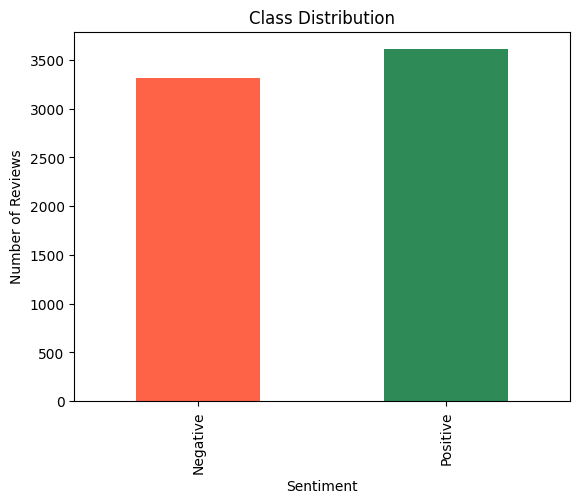

In [ ]:
import matplotlib.pyplot as plt

# Visualize class distribution
df['label'].value_counts().sort_index().plot(kind='bar', color= ["tomato", "seagreen"])
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(ticks=[0,1], labels=["Negative","Positive"])
plt.show()


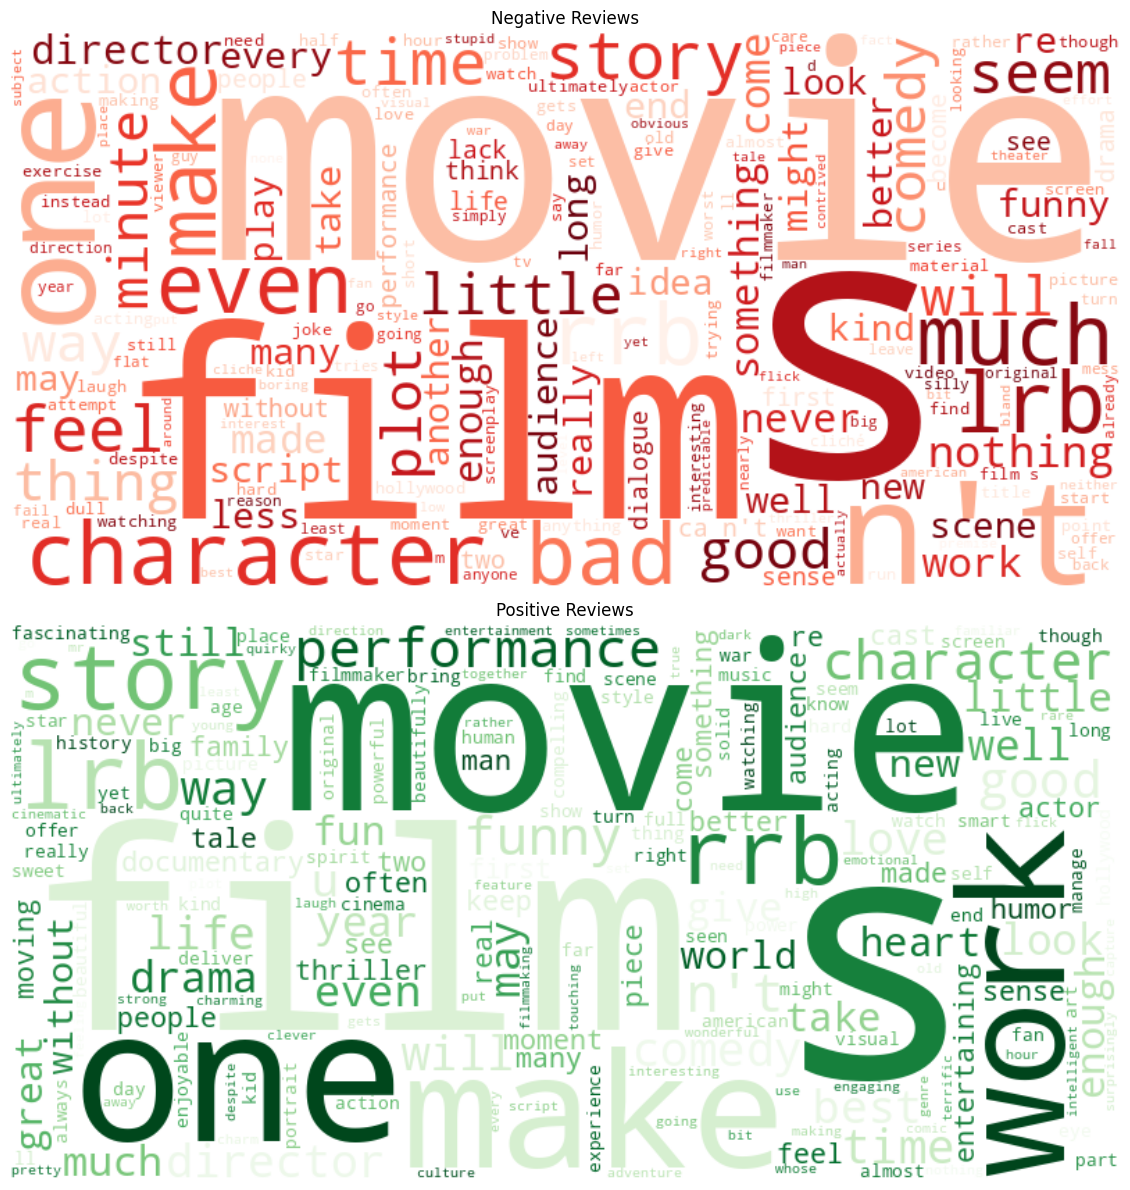

In [ ]:
# Visualize the number of positive and negative reviews with word clouds

from wordcloud import WordCloud

positive_text = " ".join(df[df["label"] == 1]["sentence"])
negative_text = " ".join(df[df["label"] == 0]["sentence"])

positive_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

negative_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(12, 12 ))

plt.subplot(2, 1, 1)
plt.imshow(negative_cloud, interpolation="bilinear")
plt.title("Negative Reviews")
plt.axis("off")

plt.subplot(2, 1, 2)
plt.imshow(positive_cloud, interpolation="bilinear")
plt.title("Positive Reviews")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
#compute review length statistics

df["review_length"] = df["sentence"].apply(lambda x: len(x.split()))

length_stats = df["review_length"].describe()

iqr = df["review_length"].quantile(0.75) - df["review_length"].quantile(0.25)

print("Review Length Statistics")
print(length_stats)
print("IQR", iqr)


Review Length Statistics
count    6920.000000
mean       19.315318
std         9.327449
min         2.000000
25%        12.000000
50%        19.000000
75%        25.000000
max        53.000000
Name: review_length, dtype: float64
IQR 13.0


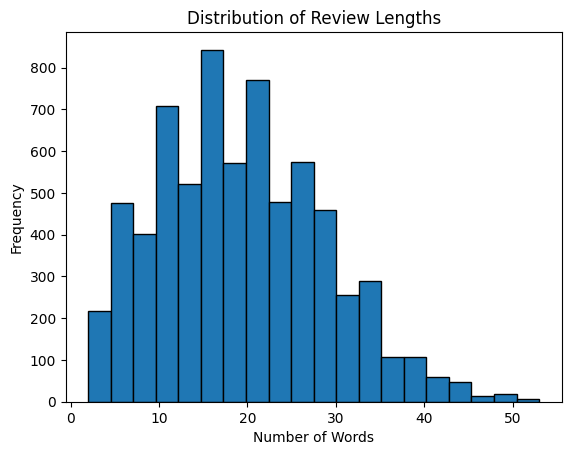

Train class distribution
label
1    0.521676
0    0.478324
Name: proportion, dtype: float64

Validation class distribution
label
1    0.521679
0    0.478321
Name: proportion, dtype: float64

Test class distribution
label
1    0.521669
0    0.478331
Name: proportion, dtype: float64


In [ ]:
plt.hist(df["review_length"], bins=20, edgecolor="black")

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#word clouds
print("Train class distribution")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation class distribution")
print(val_df["label"].value_counts(normalize=True))

print("\nTest class distribution")
print(test_df["label"].value_counts(normalize=True))




## Part 3 – Baseline Traditional Models


1. **Logistic Regression & SVM**  
    - Train at least two linear models on your TF-IDF features.  
    - Use cross-validation (≥ 5 folds) on the training set to tune at least one hyperparameter.
    

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

y_train = train_df["label"]
y_val = val_df["label"]
y_test = test_df["label"]

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg_params = {
    "C": [0.01, 0.1, 1, 10]
}

logreg_grid = GridSearchCV(
    logreg,
    logreg_params,
    cv=5,
    scoring = "f1",
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)


# Print accuracy for both models
print("best logistic regresion parameters:", logreg_grid.best_params_)
print("Logistic Regression CV F1 Score:", logreg_grid.best_score_)


best logistic regresion parameters: {'C': 1}
Logistic Regression CV F1 Score: 0.7823129553632578


In [ ]:
svm = LinearSVC(max_iter=10000, random_state=42)

svm_params = {
    "C": [0.01, 0.1, 1, 10]
}

svm_grid = GridSearchCV(
    svm,
    svm_params,
    cv=5,
    scoring = "f1",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("best svm parameters:", svm_grid.best_params_)
print("best svm cv f1 score:", svm_grid.best_score_)





best svm parameters: {'C': 0.1}
best svm cv f1 score: 0.7792876380658402


In [ ]:
#evaluate on validation set
best_svm = svm_grid.best_estimator_
svm_val_pred = best_svm.predict(X_val)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("svm validation accuracy:", accuracy_score(y_val, svm_val_pred))
print(classification_report(y_val, svm_val_pred, target_names=["negative", "positive"]))


svm validation accuracy: 0.7653131452167928
              precision    recall  f1-score   support

    negative       0.75      0.77      0.76       695
    positive       0.78      0.76      0.77       758

    accuracy                           0.77      1453
   macro avg       0.76      0.77      0.77      1453
weighted avg       0.77      0.77      0.77      1453



In [ ]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train.toarray(), y_train)



GradientBoostingClassifier(random_state=42)

In [ ]:
best_logreg = logreg_grid.best_estimator_
best_svm = svm_grid.best_estimator_


models = {
    "Logistic Regression": best_logreg,
    "linear SVM": best_svm,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

results = []

for name, model in models.items():
    if name == "Gradient Boosting":
        X_eval = X_test.toarray()
    else:
        X_eval = X_test

    y_pred = model.predict(X_eval)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_eval)
    else:
        y_score = y_pred

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results)
results_df



,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.796148,0.791176,0.827692,0.809023,0.858854
1,linear SVM,0.789727,0.790419,0.812308,0.801214,0.858224
2,Random Forest,0.707865,0.725552,0.707692,0.716511,0.778095
3,Gradient Boosting,0.677368,0.659794,0.787692,0.718093,0.731920


In [ ]:
#Random forest feature importance

feature_names = vectorizer.get_feature_names_out()

rf_importance = pd.DataFrame({
    "token": feature_names,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance.head(20)


,token,importance
230,and,0.011705
5074,too,0.008992
4980,the,0.008192
46,a,0.007604
3421,of,0.007591
3279,n,0.005873
4178,s,0.005801
2660,it,0.005621
2653,is,0.005331
5062,to,0.005068


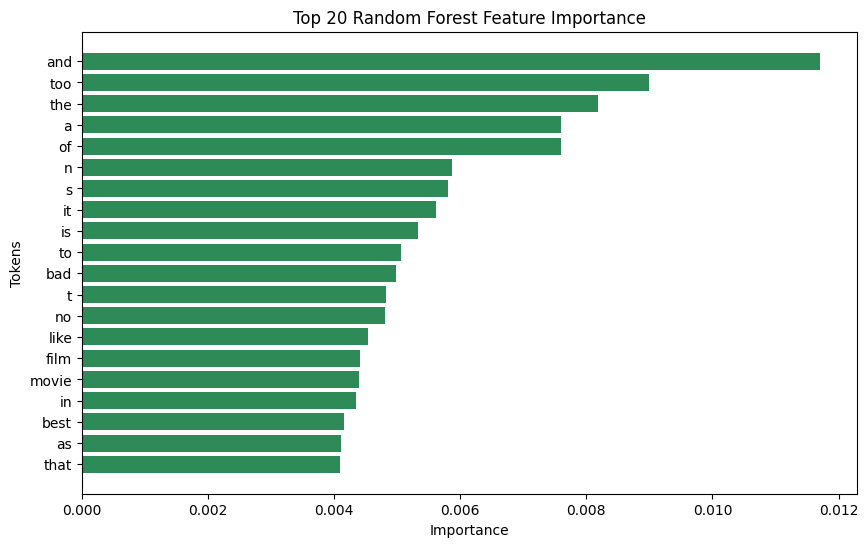

In [ ]:
#plot top 20 features

top_rf = rf_importance.head(20)
plt.figure(figsize=(10, 6))
plt.barh(top_rf["token"], top_rf["importance"], color="seagreen")
plt.gca().invert_yaxis()
plt.title("Top 20 Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Tokens")
plt.show()


In [ ]:
#Gradient boosting feature importance
gb_importance = pd.DataFrame({
    "token": feature_names,
    "importance": gb.feature_importances_
}).sort_values(by="importance", ascending=False)

gb_importance.head(20)



,token,importance
230,and,0.059393
5074,too,0.055995
3279,n,0.049855
395,bad,0.033188
479,best,0.024727
3350,no,0.021670
1496,dull,0.019144
3244,movie,0.018859
5557,worst,0.017123
2066,fun,0.017009


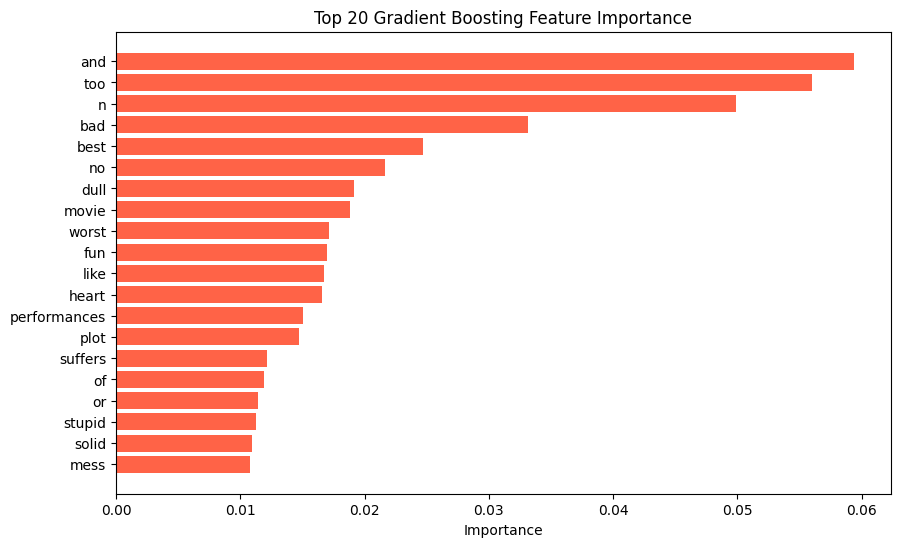

In [ ]:
top_gb = gb_importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_gb["token"], top_gb["importance"], color="tomato")
plt.xlabel("Importance")
plt.title("Top 20 Gradient Boosting Feature Importance")
plt.gca().invert_yaxis()
plt.show()


Feature importance was extracted from the fitted Random Forest and Gradient Boosting models using their feature_importances_ attributes. The highest ranked tokens represent words which contributed most strnogly to the tree based models' sentiment predictions. Comparing the top tokens across both models helps us identify words which are consistently useful for distinguising positive and negative reviews.

## Part 4 – Neural Network Models

Part 4 is the neural network stage. It has two main goals:
- convert cleaned text into fixed-length integer sequences,
- train one simple embedding + dense model and one Conv1D classifier.

The sequence pipeline maps each token to an ID and pads/truncates reviews so the model receives uniform-length input. The embedding layer then learns a dense representation for each token, while the dense and convolutional layers learn higher-level sentiment features.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

MAX_TOKENS = 5000
MAX_LEN = 100

text_vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
    output_mode='int'
)

text_vectorizer.adapt(train_df["cleaned_sentence"].astype(str))

### Padding the integer sequences

In [ ]:
X_train_seq = text_vectorizer(train_df["cleaned_sentence"].astype(str))
X_val_seq = text_vectorizer(val_df["cleaned_sentence"].astype(str))
X_test_seq = text_vectorizer(test_df["cleaned_sentence"].astype(str))

print("Shape of training sequences:", X_train_seq.shape)
print("Shape of validation sequences:", X_val_seq.shape)
print("Shape of test sequences:", X_test_seq.shape)


Shape of training sequences: (4844, 100)
Shape of validation sequences: (1453, 100)
Shape of test sequences: (623, 100)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten, GlobalAveragePooling1D, Dropout


y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

ff_mlp = Sequential([
    Embedding(input_dim=MAX_TOKENS, output_dim=128, input_shape=(MAX_LEN,), trainable=True),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

ff_mlp.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


ff_mlp.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = ff_mlp.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5167 - loss: 0.6939 - val_accuracy: 0.5217 - val_loss: 0.6921
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5211 - loss: 0.6927 - val_accuracy: 0.5217 - val_loss: 0.6916
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5225 - loss: 0.6921 - val_accuracy: 0.5217 - val_loss: 0.6915
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5264 - loss: 0.6912 - val_accuracy: 0.5217 - val_loss: 0.6878
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5545 - loss: 0.6853 - val_accuracy: 0.5802 - val_loss: 0.6756
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6288 - loss: 0.6567 - val_accuracy: 0.7213 - val_loss: 0.6184
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6697 - loss: 0.6133 - val_accuracy: 0.5272 - val_loss: 0.7319
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7322 - loss: 0.5249 - val_accuracy: 0

In [ ]:
ff_mlp.evaluate(X_test_seq, y_test)
y_pred_prob = ff_mlp.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8010 - loss: 0.4514
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy: 0.8009630818619583
Test Precision: 0.8231511254019293
Test Recall: 0.7876923076923077
Test F1 Score: 0.8050314465408805
Test ROC AUC: 0.873959731543624


### Simple Feed-Forward with Frozen Embeddings

In [ ]:
ff_mlp_frozen = Sequential([
    Embedding(input_dim=MAX_TOKENS, output_dim=128, input_shape=(MAX_LEN,), trainable=False), # Frozen embedding
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

ff_mlp_frozen.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

ff_mlp_frozen.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 640,000 (2.44 MB)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_frozen = ff_mlp_frozen.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5211 - loss: 0.6928 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5215 - loss: 0.6928 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6926 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6925 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6927 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6925 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6924 - val_accuracy: 0.5217 - val_loss: 0.6922
Epoch 8/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5217 - loss: 0.6924 - val_accuracy: 0

In [ ]:
ff_mlp_frozen.evaluate(X_test_seq, y_test)
y_pred_prob_frozen = ff_mlp_frozen.predict(X_test_seq).flatten()
y_pred_frozen = (y_pred_prob_frozen >= 0.5).astype(int)

print("Test Accuracy (Frozen Embeddings):", accuracy_score(y_test, y_pred_frozen))
print("Test Precision (Frozen Embeddings):", precision_score(y_test, y_pred_frozen))
print("Test Recall (Frozen Embeddings):", recall_score(y_test, y_pred_frozen))
print("Test F1 Score (Frozen Embeddings):", f1_score(y_test, y_pred_frozen))
print("Test ROC AUC (Frozen Embeddings):", roc_auc_score(y_test, y_pred_prob_frozen))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5217 - loss: 0.6921
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Test Accuracy (Frozen Embeddings): 0.521669341894061
Test Precision (Frozen Embeddings): 0.521669341894061
Test Recall (Frozen Embeddings): 1.0
Test F1 Score (Frozen Embeddings): 0.6856540084388185
Test ROC AUC (Frozen Embeddings): 0.5455343314403717


### Training and eval

**Convolutional Text Classifier**  
   - Implement a 1D-CNN architecture (Conv + Pooling) for sequence data.  
   - Justify your choice of kernel sizes and number of filters.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D

cnn = Sequential([
    Embedding(input_dim=MAX_TOKENS, output_dim=64, input_shape=(MAX_LEN,)),
    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

cnn.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,865 (1.33 MB)

 Trainable params: 348,865 (1.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = cnn.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)
cnn.evaluate(X_test_seq, y_test)
y_pred_prob = cnn.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))



Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5677 - loss: 0.6807 - val_accuracy: 0.6738 - val_loss: 0.6428
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7766 - loss: 0.5070 - val_accuracy: 0.7571 - val_loss: 0.4898
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8941 - loss: 0.2805 - val_accuracy: 0.7612 - val_loss: 0.5430
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9589 - loss: 0.1315 - val_accuracy: 0.7495 - val_loss: 0.6535
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9849 - loss: 0.0587 - val_accuracy: 0.7626 - val_loss: 0.8232
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7640 - loss: 0.4931
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Test Accuracy: 0.7640449438202247
Test Precision: 0.7730061349693251
Test Recall: 0.7753846153846153
Test F1 Score: 0.7741935483870968
Test ROC AUC: 0.8426535880227154


**Recurrent Model (Optional)**  
   - (Stretch) Add an RNN or Bi-LSTM layer and compare performance/time vs. CNN.

In [ ]:
from tensorflow.keras.layers import LSTM, Bidirectional

bilstm = Sequential([
    Embedding(input_dim=MAX_TOKENS, output_dim=128, input_shape=(MAX_LEN,)),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

bilstm.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

bilstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 747,137 (2.85 MB)

 Trainable params: 747,137 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = bilstm.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)


Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6214 - loss: 0.6379 - val_accuracy: 0.7392 - val_loss: 0.5187
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8340 - loss: 0.3804 - val_accuracy: 0.7639 - val_loss: 0.5181
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9199 - loss: 0.2081 - val_accuracy: 0.7543 - val_loss: 0.6274
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9531 - loss: 0.1339 - val_accuracy: 0.7543 - val_loss: 0.6863
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9725 - loss: 0.0811 - val_accuracy: 0.7440 - val_loss: 0.8955


In [ ]:
bilstm.evaluate(X_test_seq, y_test)
y_pred_prob = bilstm.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7769 - loss: 0.4870
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Test Accuracy: 0.7768860353130016
Test Precision: 0.8184931506849316
Test Recall: 0.7353846153846154
Test F1 Score: 0.7747163695299838
Test ROC AUC: 0.858378936499742


### RNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout, SimpleRNN

rnn = Sequential([
    Embedding(input_dim=MAX_TOKENS, output_dim=128, input_shape=(MAX_LEN,)),
    SimpleRNN(64),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

rnn.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,577 (2.50 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = rnn.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5058 - loss: 0.6973 - val_accuracy: 0.4969 - val_loss: 0.6934
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5142 - loss: 0.7050 - val_accuracy: 0.5203 - val_loss: 0.6940
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4944 - loss: 0.7025 - val_accuracy: 0.5299 - val_loss: 0.6917
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4990 - loss: 0.6971 - val_accuracy: 0.5327 - val_loss: 0.6917
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5091 - loss: 0.6942 - val_accuracy: 0.5217 - val_loss: 0.6921
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5031 - loss: 0.7051 - val_accuracy: 0.5010 - val_loss: 0.6970
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5054 - loss: 0.6993 - val_accuracy: 0.5265 - val_loss: 0.6917


In [ ]:
rnn.evaluate(X_test_seq, y_test)
y_pred_prob = rnn.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)


print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4992 - loss: 0.6924
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Test Accuracy: 0.49919743178170145
Test Precision: 0.5115864527629234
Test Recall: 0.8830769230769231
Test F1 Score: 0.6478555304740407
Test ROC AUC: 0.5072638100154879


## Part 5 – Transfer Learning & Advanced Architectures


1. **Pre-trained Embeddings**  
    - Retrain one network using pre-trained GloVe (or FastText) embeddings.
    - Compare results against your from-scratch embedding runs.
    

In [ ]:
import os
import zipfile

# If the file exists but is corrupted, remove it
if os.path.exists('glove.6B.zip'):
    # Basic check: if it's very small, it's definitely not the full GloVe dataset
    if os.path.getsize('glove.6B.zip') < 1000000:
        print('Removing corrupted zip file...')
        os.remove('glove.6B.zip')

# Download GloVe embeddings
if not os.path.exists('glove.6B.zip'):
    print('Downloading GloVe embeddings...')
    !wget http://nlp.stanford.edu/data/glove.6B.zip

# Extract the specific 100d file
try:
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        if 'glove.6B.100d.txt' not in os.listdir('.'):
            print('Extracting glove.6B.100d.txt...')
            z.extract('glove.6B.100d.txt')
            print('Extraction complete.')
        else:
            print('File already extracted.')
except zipfile.BadZipFile:
    print('Zip file is still corrupted. Removing it. Please run the cell again.')
    os.remove('glove.6B.zip')

--2026-05-03 16:33:04--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-03 16:33:04--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-03 16:33:04--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
glove_idx = {}
with open("glove.6B.100d.txt", "r", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = list(map(float, values[1:]))
        glove_idx[word] = vector



In [ ]:
vocab = text_vectorizer.get_vocabulary()
vocab_size = len(vocab)
embedding_dim = 100

In [ ]:
import numpy as np

present_words = 0
absent_words = 0

embedding_matrix = np.zeros((vocab_size, embedding_dim))
for idx, word in enumerate(vocab):
    if word in glove_idx:
        embedding_matrix[idx] = glove_idx[word]
        present_words += 1
    else:
        absent_words += 1

print(f"Present words in GloVe: {present_words}")
print(f"Absent words in GloVe: {absent_words}")

Present words in GloVe: 4984
Absent words in GloVe: 16


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Conv1D, GlobalMaxPooling1D, Dropout, Input


glove_model = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=MAX_LEN,
        weights=[embedding_matrix],
        trainable=False),
    Conv1D(filters=128, kernel_size=5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

glove_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

glove_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 96, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 572,449 (2.18 MB)

 Trainable params: 72,449 (283.00 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_glove = glove_model.fit(
    X_train_seq,
    y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping]
)



Epoch 1/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6078 - loss: 0.6573 - val_accuracy: 0.6965 - val_loss: 0.5915
Epoch 2/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7267 - loss: 0.5393 - val_accuracy: 0.7467 - val_loss: 0.5189
Epoch 3/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7971 - loss: 0.4392 - val_accuracy: 0.7612 - val_loss: 0.5006
Epoch 4/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8520 - loss: 0.3513 - val_accuracy: 0.7584 - val_loss: 0.4945
Epoch 5/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9030 - loss: 0.2540 - val_accuracy: 0.7529 - val_loss: 0.5317
Epoch 6/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9321 - loss: 0.1813 - val_accuracy: 0.7302 - val_loss: 0.6147
Epoch 7/20
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9666 - loss: 0.1047 - val_accuracy: 0.7467 - val_loss: 0.6741


In [ ]:
glove_model.evaluate(X_test_seq, y_test)
y_pred_prob = glove_model.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7753 - loss: 0.4828
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Test Accuracy: 0.7752808988764045
Test Precision: 0.7650429799426934
Test Recall: 0.8215384615384616
Test F1 Score: 0.7922848664688428
Test ROC AUC: 0.8537635518843572


### BERT fine tuning

In [ ]:
!pip install transformers
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset, Dataset
import torch
from torch.optim import AdamW

In [ ]:
# tokenizing, we are using distillbert in this case faster compare to the fuyll bert to train
from transformers import AutoTokenizer

tokenizer = BertTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_sentences(sentences, labels, tokenizer, max_len=128):
    encodings = tokenizer(
        list(sentences),
        truncation=True,
        padding=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return encodings, torch.tensor(labels.values, dtype=torch.long)

train_encodings, y_train = tokenize_sentences(train_df["cleaned_sentence"], train_df["label"], tokenizer)
val_encodings, y_val = tokenize_sentences(val_df["cleaned_sentence"], val_df["label"], tokenizer)
test_encodings, y_test = tokenize_sentences(test_df["cleaned_sentence"], test_df["label"], tokenizer)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## creating the dataset to use

In [ ]:
class SST2Dataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx]
        }

training_dataset = SST2Dataset(train_encodings, y_train)
validating_dataset = SST2Dataset(val_encodings, y_val)
testing_dataset = SST2Dataset(test_encodings, y_test)

### Loading the model


In [ ]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

## distill_model = distill_model.to(device)

print(f"Using device: {device}")

Using device: cuda


In [ ]:
from transformers import DistilBertForSequenceClassification


distill_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

optimizer = AdamW(distill_model.parameters(), lr=2e-5)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
EPOCHS = 20
learning_rate = 2e-5
batch_size = 8 # Reduced batch size from 16 to 8 oom error

train_loader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(validating_dataset, batch_size=batch_size)
test_loader = DataLoader(testing_dataset, batch_size=batch_size)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=2)


In [ ]:
## training loop

optimizer = AdamW(distill_model.parameters(), lr=learning_rate)

for epoch in range(EPOCHS):
    distill_model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = distill_model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)

    distill_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = distill_model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

    avg_val_loss = val_loss / len(val_loader)
    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/20 - Train Loss: 0.3779 - Val Loss: 0.2655
Epoch 2/20 - Train Loss: 0.1636 - Val Loss: 0.3132
Epoch 3/20 - Train Loss: 0.0700 - Val Loss: 0.3294
Epoch 4/20 - Train Loss: 0.0381 - Val Loss: 0.4220
Epoch 5/20 - Train Loss: 0.0233 - Val Loss: 0.5424
Epoch 6/20 - Train Loss: 0.0238 - Val Loss: 0.5704
Epoch 7/20 - Train Loss: 0.0172 - Val Loss: 0.5339
Epoch 8/20 - Train Loss: 0.0159 - Val Loss: 0.5082
Epoch 9/20 - Train Loss: 0.0110 - Val Loss: 0.4887
Epoch 10/20 - Train Loss: 0.0158 - Val Loss: 0.4963
Epoch 11/20 - Train Loss: 0.0049 - Val Loss: 0.7299
Epoch 12/20 - Train Loss: 0.0116 - Val Loss: 0.5830
Epoch 13/20 - Train Loss: 0.0046 - Val Loss: 0.8602
Epoch 14/20 - Train Loss: 0.0088 - Val Loss: 0.6997
Epoch 15/20 - Train Loss: 0.0128 - Val Loss: 0.6340
Epoch 16/20 - Train Loss: 0.0082 - Val Loss: 0.5606
Epoch 17/20 - Train Loss: 0.0082 - Val Loss: 0.7581
Epoch 18/20 - Train Loss: 0.0128 - Val Loss: 0.5080
Epoch 19/20 - Train Loss: 0.0018 - Val Loss: 0.6460
Epoch 20/20 - Train L

In [ ]:
# evaluating the model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
distill_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to("cuda")
        attention_mask = batch["attention_mask"].to("cuda")
        labels = batch["labels"].to("cuda")

        outputs = distill_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)


print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Test Precision:", precision_score(all_labels, all_preds))
print("Test Recall:", recall_score(all_labels, all_preds))
print("Test F1 Score:", f1_score(all_labels, all_preds))
print("Test ROC AUC:", roc_auc_score(all_labels, all_probs))


Test Accuracy: 0.8876404494382022
Test Precision: 0.8805970149253731
Test Recall: 0.9076923076923077
Test F1 Score: 0.8939393939393939
Test ROC AUC: 0.9474961280330407


## Part 6 – Hyperparameter Optimization


1. **Search Strategy**  
    - Use a library (e.g., Keras Tuner, Optuna) to optimize at least two hyperparameters of one deep model.
    - Describe your search space and stopping criteria.
    

In [ ]:
!pip install keras-tuner

from kerastuner import HyperModel
from kerastuner.tuners import RandomSearch
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.2 MB/s eta 0:00:00


/tmp/ipykernel_2626/164511281.py:3: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel


In [ ]:
class CNNHyperModel(HyperModel):
    def __init__(self, vocab_size, embedding_dim, max_len):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_len = max_len

    def build(self, hp):
        model = Sequential([
            Input(shape=(self.max_len,)),
            Embedding(input_dim=self.vocab_size, output_dim=self.embedding_dim, input_length=self.max_len),
            Conv1D(
                filters=hp.Int("filters", min_value=64, max_value=256, step=64),
                kernel_size=hp.Choice("kernel_size", values=[3, 5]),
                activation="relu"
            ),
            GlobalMaxPooling1D(),
            Dense(
                units=hp.Int("dense_units", min_value=32, max_value=128, step=32),
                activation="relu"
            ),
            Dropout(rate=hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            loss="binary_crossentropy",
            optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="LOG")),
            metrics=["accuracy"]
        )

        return model

In [ ]:
## tuner for our cnn
cnn_tune = RandomSearch(
    CNNHyperModel(vocab_size=vocab_size, embedding_dim=embedding_dim, max_len=MAX_LEN),
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    directory="cnn_tuning",
    project_name="sentiment_analysis"
)

cnn_tune.search(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=10, batch_size=32)

best_cnn = cnn_tune.get_best_models(num_models=1)[0]
best_cnn.summary()
best_params = cnn_tune.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_params.values)
best_cnn.evaluate(X_test_seq, y_test)
y_pred_prob = best_cnn.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))

print("Best Hyperparameters:", best_params.values)


Trial 10 Complete [00h 00m 30s]
val_accuracy: 0.7684101760387421

Best val_accuracy So Far: 0.7739160358905792
Total elapsed time: 00h 06m 51s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 98, 128)        │        38,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 551,009 (2.10 MB)

 Trainable params: 551,009 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Best Hyperparameters: {'filters': 128, 'kernel_size': 3, 'dense_units': 96, 'dropout_rate': 0.2, 'learning_rate': 0.0003401691826873532}
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7737 - loss: 0.5675
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Test Accuracy: 0.7736757624398074
Test Precision: 0.7705882352941177
Test Recall: 0.8061538461538461
Test F1 Score: 0.7879699248120301
Test ROC AUC: 0.8524109447599381
Best Hyperparameters: {'filters': 128, 'kernel_size': 3, 'dense_units': 96, 'dropout_rate': 0.2, 'learning_rate': 0.0003401691826873532}


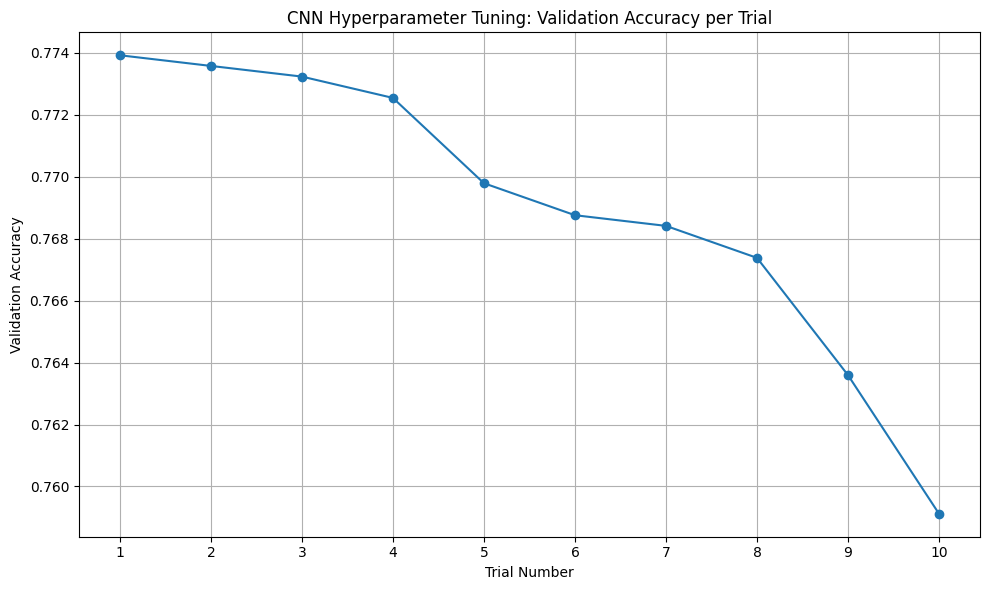

In [ ]:
import matplotlib.pyplot as plt

# Get the trials from the tuner
trials = cnn_tune.oracle.get_best_trials(num_trials=cnn_tune.oracle.max_trials)

trial_accuracies = []
for i, trial in enumerate(trials):
    # Each trial might have multiple epochs; we care about the best validation accuracy achieved in that trial
    # Check if 'val_accuracy' exists in the trial metrics before attempting to access it
    if 'val_accuracy' in trial.metrics.metrics:
        trial_accuracies.append(trial.metrics.metrics['val_accuracy'].get_best_value())
    else:
        # Handle cases where 'val_accuracy' might not be available for a trial
        trial_accuracies.append(None)

# Filter out None values for plotting
plot_accuracies = [acc for acc in trial_accuracies if acc is not None]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(plot_accuracies) + 1), plot_accuracies, marker='o')
plt.title('CNN Hyperparameter Tuning: Validation Accuracy per Trial')
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.xticks(range(1, len(plot_accuracies) + 1))
plt.tight_layout()
plt.show()

## Checking for RNN

In [ ]:
class RNNHyperModel(HyperModel):
    def __init__(self, vocab_size, embedding_dim, max_len):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_len = max_len

    def build(self, hp):
        model = Sequential([
            Input(shape=(self.max_len,)),
            Embedding(input_dim=self.vocab_size, output_dim=self.embedding_dim, input_length=self.max_len),
            SimpleRNN(
                units=hp.Int("rnn_units", min_value=32, max_value=128, step=32),
                activation="tanh"
            ),
            Dense(
                units=hp.Int("dense_units", min_value=32, max_value=128, step=32),
                activation="relu"
            ),
            Dropout(rate=hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            loss="binary_crossentropy",
            optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="LOG")),
            metrics=["accuracy"]
        )

        return model

In [ ]:
# tuner for our rnn
rnn_tune = RandomSearch(
    RNNHyperModel(vocab_size=vocab_size, embedding_dim=embedding_dim, max_len=MAX_LEN),
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    directory="rnn_tuning",
    project_name="sentiment_analysis"
)

rnn_tune.search(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=10, batch_size=32)
best_rnn = rnn_tune.get_best_models(num_models=1)[0]
best_rnn.summary()
best_params = rnn_tune.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_params.values)
best_rnn.evaluate(X_test_seq, y_test)
y_pred_prob = best_rnn.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))

Trial 10 Complete [00h 00m 54s]
val_accuracy: 0.5316586494445801

Best val_accuracy So Far: 0.682381272315979
Total elapsed time: 00h 08m 56s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 541,793 (2.07 MB)

 Trainable params: 541,793 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

Best Hyperparameters: {'rnn_units': 128, 'dense_units': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00018688585818382088}
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6966 - loss: 0.9807
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Test Accuracy: 0.6966292134831461
Test Precision: 0.717948717948718
Test Recall: 0.6892307692307692
Test F1 Score: 0.7032967032967034
Test ROC AUC: 0.7370211667527103


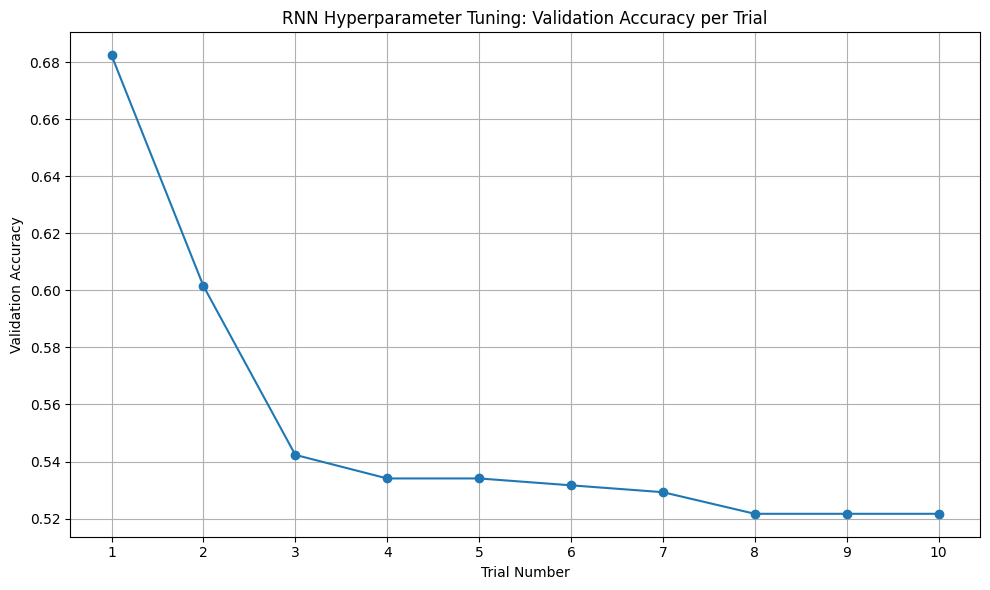

In [ ]:
import matplotlib.pyplot as plt

# Get the trials from the tuner
trials_rnn = rnn_tune.oracle.get_best_trials(num_trials=rnn_tune.oracle.max_trials)

trial_accuracies_rnn = []
for i, trial in enumerate(trials_rnn):
    # Each trial might have multiple epochs; we care about the best validation accuracy achieved in that trial
    # Check if 'val_accuracy' exists in the trial metrics before attempting to access it
    if 'val_accuracy' in trial.metrics.metrics:
        trial_accuracies_rnn.append(trial.metrics.metrics['val_accuracy'].get_best_value())
    else:
        # Handle cases where 'val_accuracy' might not be available for a trial
        trial_accuracies_rnn.append(None)

# Filter out None values for plotting
plot_accuracies_rnn = [acc for acc in trial_accuracies_rnn if acc is not None]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(plot_accuracies_rnn) + 1), plot_accuracies_rnn, marker='o')
plt.title('RNN Hyperparameter Tuning: Validation Accuracy per Trial')
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.xticks(range(1, len(plot_accuracies_rnn) + 1))
plt.tight_layout()
plt.show()

### hyperparam tuning for bilstm

In [ ]:
class biLSTMHyperModel(HyperModel):
    def __init__(self, vocab_size, embedding_dim, max_len):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.max_len = max_len

    def build(self, hp):
        model = Sequential([
            Input(shape=(self.max_len,)),
            Embedding(input_dim=self.vocab_size, output_dim=self.embedding_dim, input_length=self.max_len),
            Bidirectional(LSTM(
                units=hp.Int("lstm_units", min_value=32, max_value=128, step=32),
                activation="tanh"
            )),
            Dense(
                units=hp.Int("dense_units", min_value=32, max_value=128, step=32),
                activation="relu"
            ),
            Dropout(rate=hp.Float("dropout_rate", min_value=0.2, max_value=0.5, step=0.1)),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            loss="binary_crossentropy",
            optimizer=Adam(hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="LOG")),
            metrics=["accuracy"]
        )

        return model

In [ ]:
bilstm_tune = RandomSearch(
    biLSTMHyperModel(vocab_size=vocab_size, embedding_dim=embedding_dim, max_len=MAX_LEN),
    objective="val_accuracy",
    max_trials=10,
    executions_per_trial=2,
    directory="bilstm_tuning",
    project_name="sentiment_analysis"
)

bilstm_tune.search(X_train_seq, y_train, validation_data=(X_val_seq, y_val), epochs=10, batch_size=32)
best_bilstm = bilstm_tune.get_best_models(num_models=1)[0]
best_bilstm.summary()
best_params = bilstm_tune.get_best_hyperparameters(num_trials=1)[0]
print("Best Hyperparameters:", best_params.values)
best_bilstm.evaluate(X_test_seq, y_test)
y_pred_prob = best_bilstm.predict(X_test_seq).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test F1 Score:", f1_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_pred_prob))


Trial 10 Complete [00h 01m 05s]
val_accuracy: 0.7763248383998871

Best val_accuracy So Far: 0.7763248383998871
Total elapsed time: 00h 10m 10s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 24 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        34,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 540,385 (2.06 MB)

 Trainable params: 540,385 (2.06 MB)

 Non-trainable params: 0 (0.00 B)

Best Hyperparameters: {'lstm_units': 32, 'dense_units': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.004450164186611188}
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7689 - loss: 0.5264
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Test Accuracy: 0.7688603531300161
Test Precision: 0.7669616519174042
Test Recall: 0.8
Test F1 Score: 0.7831325301204819
Test ROC AUC: 0.8439752194114611


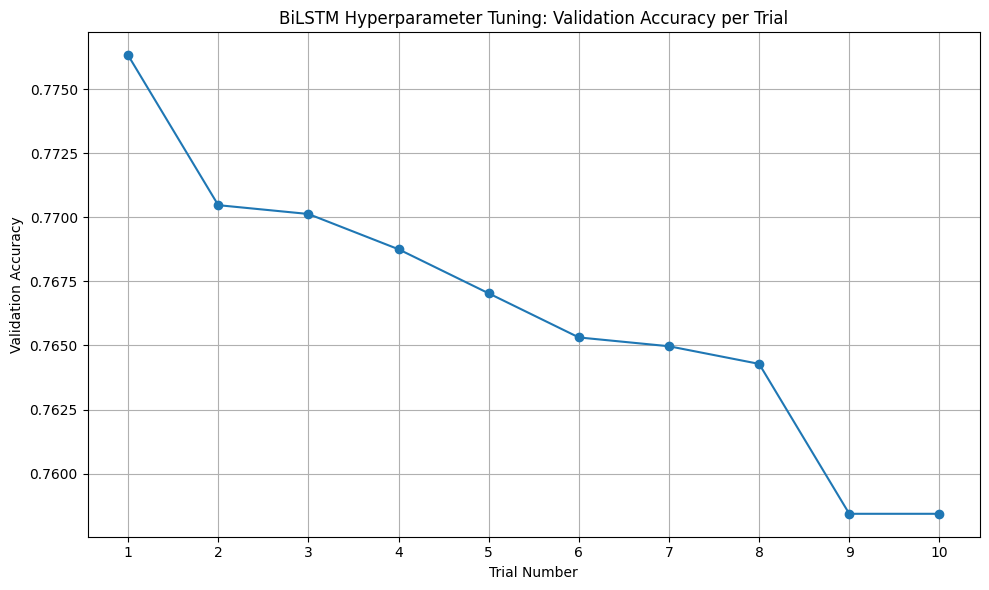

In [ ]:
import matplotlib.pyplot as plt

# Get the trials from the tuner
trials_bilstm = bilstm_tune.oracle.get_best_trials(num_trials=bilstm_tune.oracle.max_trials)

trial_accuracies_bilstm = []
for i, trial in enumerate(trials_bilstm):
    # Each trial might have multiple epochs; we care about the best validation accuracy achieved in that trial
    # Check if 'val_accuracy' exists in the trial metrics before attempting to access it
    if 'val_accuracy' in trial.metrics.metrics:
        trial_accuracies_bilstm.append(trial.metrics.metrics['val_accuracy'].get_best_value())
    else:
        # Handle cases where 'val_accuracy' might not be available for a trial
        trial_accuracies_bilstm.append(None)

# Filter out None values for plotting
plot_accuracies_bilstm = [acc for acc in trial_accuracies_bilstm if acc is not None]

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(plot_accuracies_bilstm) + 1), plot_accuracies_bilstm, marker='o')
plt.title('BiLSTM Hyperparameter Tuning: Validation Accuracy per Trial')
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.xticks(range(1, len(plot_accuracies_bilstm) + 1))
plt.tight_layout()
plt.show()

### Consolidated Hyperparameter Tuning Results

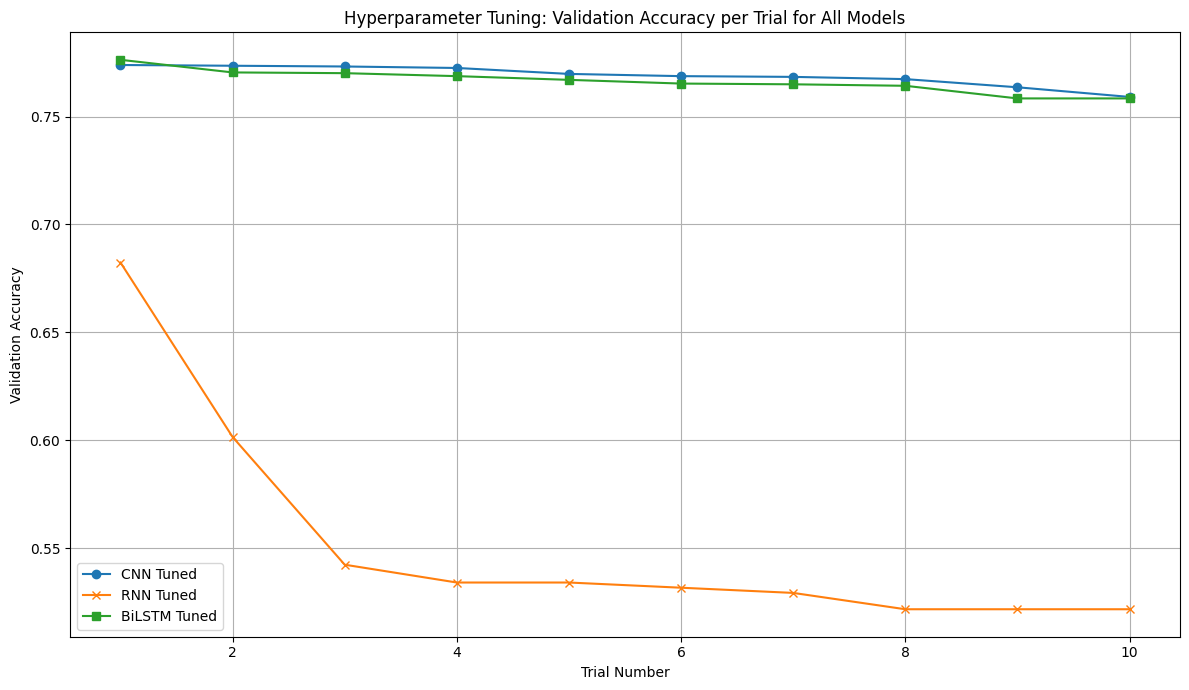

In [ ]:
plt.figure(figsize=(12, 7))

# Plot CNN results (from previous execution, 'plot_accuracies' was the variable name)
plt.plot(range(1, len(plot_accuracies) + 1), plot_accuracies, marker='o', label='CNN Tuned')

# Plot RNN results
plt.plot(range(1, len(plot_accuracies_rnn) + 1), plot_accuracies_rnn, marker='x', label='RNN Tuned')

# Plot BiLSTM results
plt.plot(range(1, len(plot_accuracies_bilstm) + 1), plot_accuracies_bilstm, marker='s', label='BiLSTM Tuned')

plt.title('Hyperparameter Tuning: Validation Accuracy per Trial for All Models')
plt.xlabel('Trial Number')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Part 7 – Final Comparison & Error Analysis


1. **Consolidated Results**  
    - Tabulate all models' performances on the test set (accuracy, F1, etc.)
    - Identify the best-performing model and its hyperparameters.
    

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def eval_keras_model(model, X, y):
    y_pred_prob = model.predict(X).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
        "ROC AUC": roc_auc_score(y, y_pred_prob)
    }

def eval_sklearn_model(model, X, y):
    y_pred = model.predict(X)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X)
    else:
        y_score = y_pred
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
        "ROC AUC": roc_auc_score(y, y_score)
    }

# Legacy neural models
legacy_neural = {
    "CNN (legacy)": cnn,
    "BiLSTM (legacy)": bilstm,
    "RNN (legacy)": rnn,
    "GloVe CNN (legacy)": glove_model
}

# Tuned neural models
tuned_neural = {
    "CNN (tuned)": best_cnn,
    "BiLSTM (tuned)": best_bilstm,
    "RNN (tuned)": best_rnn
}

# Legacy classical models
legacy_classical = {
    "Logistic Regression": best_logreg,
    "Linear SVM": best_svm,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

legacy_results = []
for name, model in legacy_classical.items():
    X_eval = X_test.toarray() if name == "Gradient Boosting" else X_test
    legacy_results.append(
        {"Model": name, "Category": "Classical", **eval_sklearn_model(model, X_eval, y_test)}
    )

for name, model in legacy_neural.items():
    if model is None:
        continue
    legacy_results.append(
        {"Model": name, "Category": "Neural (legacy)", **eval_keras_model(model, X_test_seq, y_test)}
    )

tuned_results = []
for name, model in tuned_neural.items():
    if model is None:
        continue
    tuned_results.append(
        {"Model": name, "Category": "Neural (tuned)", **eval_keras_model(model, X_test_seq, y_test)}
    )

# Add DistilBERT if available
if "distill_model" in globals():
    distil_preds = []
    distil_probs = []
    distil_labels = []
    distill_model.eval()

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = distill_model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            distil_probs.extend(probs)
            distil_preds.extend(preds)
            distil_labels.extend(labels.cpu().numpy())

    tuned_results.append({
        "Model": "DistilBERT",
        "Category": "Transformer",
        "Accuracy": accuracy_score(distil_labels, distil_preds),
        "Precision": precision_score(distil_labels, distil_preds),
        "Recall": recall_score(distil_labels, distil_preds),
        "F1 Score": f1_score(distil_labels, distil_preds),
        "ROC AUC": roc_auc_score(distil_labels, distil_probs)
    })

legacy_df = pd.DataFrame(legacy_results)
tuned_df = pd.DataFrame(tuned_results)
summary_df = pd.concat([legacy_df, tuned_df], ignore_index=True)

summary_df = summary_df.sort_values(by=["Category", "F1 Score"], ascending=[True, False]).reset_index(drop=True)

print("Legacy + Hyperparameter-Tuned Model Results")
display(summary_df)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Legacy + Hyperparameter-Tuned Model Results


,Model,Category,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,Classical,0.796148,0.791176,0.827692,0.809023,0.858854
1,Linear SVM,Classical,0.789727,0.790419,0.812308,0.801214,0.858224
2,Gradient Boosting,Classical,0.677368,0.659794,0.787692,0.718093,0.731920
3,Random Forest,Classical,0.707865,0.725552,0.707692,0.716511,0.778095
4,GloVe CNN (legacy),Neural (legacy),0.775281,0.765043,0.821538,0.792285,0.853764
5,BiLSTM (legacy),Neural (legacy),0.776886,0.818493,0.735385,0.774716,0.858379
6,CNN (legacy),Neural (legacy),0.764045,0.773006,0.775385,0.774194,0.842654
7,RNN (legacy),Neural (legacy),0.499197,0.511586,0.883077,0.647856,0.507264
8,CNN (tuned),Neural (tuned),0.773676,0.770588,0.806154,0.787970,0.852411
9,BiLSTM (tuned),Neural (tuned),0.768860,0.766962,0.800000,0.783133,0.843975


## Part 8 – Optional Challenge Extensions


1. **Data Augmentation**  
    - Implement data augmentation for text (back-translation, synonym swapping) and measure its impact.
    

In [ ]:
import pandas as pd
# Example for back-translation using a library
!pip install googletrans==4.0.0-rc1
!pip install httpx==0.23.0 httpcore==0.15.0
from googletrans import Translator

translator = Translator()
df['augmented_review'] = df['sentence'].apply(lambda x: translator.translate(x, src='en', dest='fr').text)
df['augmented_review'] = df['augmented_review'].apply(lambda x: translator.translate(x, src='fr', dest='en').text)
df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 6.1 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=d053d8ef893dfa51aaa35b883ef73701ef1a0f1facf13a6f34d9e3617c6d1335
  Stored in directory: /root/.cache/pip/wheels/95/0f/04/b17a72024b56a60e499ce1a6313d283ed5ba332407155bee03
Successfully built googletrans
  Attempting uninstall: hyperframe
    Found existing installation: hyperframe 6.1.0
    Uninstalling hyperfra

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: h11
    Found existing installation: h11 0.9.0
    Uninstalling h11-0.9.0:
      Successfully uninstalled h11-0.9.0
  Attempting uninstall: anyio
    Found existing installation: anyio 4.13.0
    Uninstalling anyio-4.13.0:
      Successfully uninstalled anyio-4.13.0
  Attempting uninstall: httpcore
    Found existing installation: httpcore 0.9.1
    Uninstalling httpcore-0.9.1:
      Successfully uninstalled httpcore-0.9.1
  Attempting uninstall: httpx
    Found existing installation: httpx 0.13.3
    Uninstalling httpx-0.13.3:
      Successfully uninstalled httpx-0.13.3
ERROR:

AttributeError: module 'httpcore' has no attribute 'SyncHTTPTransport'

---

# Reflecting


**Answer the following inference questions:**



### Part 1 – Data Ingestion & Preprocessing

1. **Data Loading**  
   - How do you ensure that your dataset is properly split into training, validation, and test sets, and why is class balance important during data splitting?

We used stratified sampling to split the dataset into training, validation, and test sets. We used stratified sampling in order to preserve the same proportion of positive and negative reviews in each split. Otherwise we risk one class being overrepresented, which would bias sentiment models. E.g. if there are more positive than negative reviews, the model might learn to predict positive too often and still appear accurate. Keeping class balance helps make training, validation, and final testing more reliable.

2. **Text Cleaning & Tokenization**  
   - What is the role of tokenization in text preprocessing, and how does it impact the model's performance?

Tokenization converts raw text into smaller units, usually words or subwords. This lets the model process the text numerically. Since ML models can't directly understand raw sentences, tokenization is necessary before vectorization methods like TF-IDF. Good tokenization helps preserve meaningful words while removing noise, which can improve model performance. Poor tokenization can create messy or inconsistent features, e.g. treating "good" and "good!" as different words.

### Part 2 – Exploratory Data Analysis (EDA)

1. **Class Distribution**  
   - How does the class distribution (positive vs negative reviews) impact the model’s performance, and what strategies can be used if the dataset is imbalanced?

Class distribution shows whether the dataset has a balanced no. of positive and negative reviews. On an imbalanced dataset, the model may perform better on the majority class, and worse on the minority class. Even so, the model might still show high accuracy. This is misleading because the model may look good overall, but fails on one sentiment category.

If the dataset is imbalanced, we can use strategies such as stratified sampling, class weights, oversampling the minority class, undersampling the majority class, evaluating with precision, recall, and F1 score instead of assessing accuracy alone.

2. **Text Characteristics**  
   - What insights can be gained from visualizing word clouds for each sentiment class, and how can it improve feature engineering?
Word clouds help visualise which words appear most often in positive nad negative reviews. This reveals patterns in language. E.g. positive reviews use words such as "good", "funny", negative reviews may use words such as "bad", "boring". These early insights can improve feature engineering by identifying important sentiment related words, possible stop words, repeated terms, words which needspecial handling during preprocessing. Word clouds are helpful for understanding the dataset, but not enough for modeling by themselves.

### Part 3 – Baseline Traditional Models

1. **Logistic Regression & SVM**  
   - Why do you use cross-validation when training models like logistic regression or SVM, and how does it help prevent overfitting?
   We used cross-validation to evaluate how well a model generalises to unseen data. Instead of training and testing on one fixed split, 5 fold cross-validation divides the training data into 5 parts, trains on 4 parts, and validates on the last remaining part. This process repeats 5x, so every part is used for validation once. This helps prevent overfitting because the model is evaluated across multiple subsets of the training data, rather than being tuned to one lucky split. In this project, cross-validation was also used with grid search to choose the best regularisation parameter C for Logistic Regression and Linear SVM.

2. **Random Forest & Gradient Boosting**  
   - What role does feature importance play in interpreting Random Forest or XGBoost models?
Feature importance helps interpret tree-based models by showing which tokens contributed most to the model's predictions. In sentiment analysis, important features may include words which strongly suggest positive or negative sentiments, e.g. "good", "bad", "exciting", "boring". From Random Forest and Gradient Boosting, feature importance helps explain which words the model relied on most when classifying reviews. This makes the model less of a black box, and reveals if it's learning meaningful sentiment patterns, or relying on noisy / unhelpful words.

### Part 4 – Neural Network Models

1. **Simple Feed-Forward**  
   - Why is embedding freezing used when training neural networks on pre-trained embeddings, and how does it affect model performance?

Embedding freezing is used when training NNs on pretrained embeddings so that the weights are not updated during backpropagation during the training cycle. When using a small training dataset, allowing the weights to update during training may lead to overfitting of the model as the weights are drifted from the pre-trained values and move towards the task-specific values affecting the model's generalizability. Freezing also reduces the number of trainable parameters thus resulting to faster training of the model. In our case, we compare a simple FF + MLP with trainable parameters and a simple FF + MLP with frozen parameters and we observed stronger performance for our trainable simple FF + MLP model achieving an acccuracy of 0.79 compared to 0.52 of our frozen model. This, together with the recall of 1.0 indicates that the frozen model predicted everything as positive instead of learning the decision boundary for better classification as the embeddings did not learn.


2. **Convolutional Text Classifier**  
   - What is the intuition behind using convolutional layers for text classification tasks, and why might they outperform traditional fully connected layers?

Convolutional layers are used in text classification tasks because they can detect local word patterns that carry the sentiments useful for better text classification tasks. In our case, we use a Convolution layer with kernel size of 3, thus ensuring the model to look at sequences of 3 words at a time, thus enhancing its understanding of short phrase features used in the classification tasks. We also use 128 filters thus allowing the model to learn many different sentiment patterns, ensuring better classification. We also use GlobalMaxPooling to keep the strongest signal detected by the filters, thus allowing us to keep the strongest sentiment within the phrase.

The CNN models can outperform the traditional fully connected layers because they preserve the local word ordering and with use of GlobalMaxPooling and short windows gets both phrase level semantics and they preserve the strongest one in phrases. However, for simple FF + MLP, we use GlobalAveragePooling which averages every word together thus losing the phrase level meanings that may affect the classification performance. In our case, the simple FF + MLP outperforms the CNN.


### Part 5 – Transfer Learning & Advanced Architectures

1. **Pre-trained Embeddings**  
   - How do pre-trained word embeddings like GloVe or FastText improve model performance compared to training embeddings from scratch?

Pretrained embeddings like GloVe and FastText improve model performance by providing a strong starting point for the models compared to training embeddings from scratch. This is because when training from scratch, there is a lot of noise as the embeddings begin with random values. Using pre-trained word embeddings also improves the performance by forcing the model to learn word meanings from the provided data, and enhance generalizability of the model as the pre-trained word embeddings are typically trained from a larger corpus of data and thus words with the same meanings tend to have the similar vector representations.

In our notebook, the GloVe CNN used pre-trained 100-dimensional GloVe embeddings. The model found 4,984 words in GloVe and only 16 words were missing, meaning most of the vocabulary had useful pre-trained representations. This helped the CNN improve from an F1 score of 0.78 in the original CNN to 0.79 with GloVe embeddings.

2. **Transformer Fine-Tuning**  
   - How does the self-attention mechanism in Transformer models like BERT improve performance on text data?


The self-attention mechanism in Transformer models improve their performance on text data as it enables them to understand and capture the relationship between words in a sequence despite of the distance from each other. This allows the models to get an understanding of both the long-range dependencies and context-dependent meanings and focusing on the relevant words through attention weights thus enhanced feature representation. Consequently, this improves their performance on text data compared to our previous models.

In our experiments, the distillBert model performed better getting an accuracy of 0.87 which was higher than other traditional models we experimented with.



### Part 6 – Hyperparameter Optimization

1. **Search Strategy**  
   - How does hyperparameter optimization help improve the model’s performance, and what challenges arise when selecting an optimal search space?

Hyperparameter optimization helps improve the model's performance by systematically choosing the optimal hyperparameters that govern the training process of models such as the learning rate, batch size, etc. This is because picking the optimal hyperparameters improves the model's performance by enhancing better generalization, achievement of higher accuracy and faster convergence of the models. From our experiments, we noticed an improvement in the performance of all our neural networks across the board after hyperparameter optimization compared to the initial legacy runs.

Some of the challenges that arise when selecting an optimal search space include the high dimensionality of the parameters. As we search for optimal hyperparameters, the search space increases exponentially thus increasing the amount of time and resources needed to determine the optimal hyperparameters. The other challenge is the problem of poorly defined ranges which affect the search space as when the search space is narrow, the tuner may never find the optimal values as the best values may be excluded. The hyperparameter optimization is also a challenging task as there are no weights or learned gradients that guide the process, and needs full training runs for the optimal hyperparameters to be determined.

2. **Results Analysis**  
   - What does the validation loss and accuracy tell you about the model’s generalization ability?

Validation loss and validation accuracy show us the model's generalization ability on unseen data. This helps us understand and confirm whether the model simply memorizes the training data or learns. Validation loss gives us an understanding of how confident the model is in its predictions and the validation accuracy measures the percentage of the accurate predictions by the model. During the training cycle, they also help us to understand whether the model overfits or performs well, as on overfitting, the validation accuracy platueaus while the training loss increases or when the validation loss increases and the training loss decreases. They can also indicate underfitting when the validation loss and validation accuracy stagnates.

### Part 7 – Final Comparison & Error Analysis

1. **Consolidated Results**  
   - How do you compare models with different architectures (e.g., logistic regression vs. BERT) to select the best model for deployment?

When comparing models with different architectures for deployment, we would not focus only on which model is more recent or more complex. Instead, we would compare all models using the same validation and test sets, along with the same evaluation metrics, such as accuracy, precision, recall, F1 score, and ROC AUC. This is important because the decision should be based on how well each model performs on unseen data for the specific task, not simply on the sophistication of the architecture.

This comparison helps us fairly evaluate simpler models like Logistic Regression against more advanced models like DistilBERT. DistilBERT achieved the strongest overall performance, with an F1 score of about 0.882 and ROC AUC of 0.943, while Logistic Regression achieved an F1 score of about 0.809. Based on predictive performance alone, DistilBERT would be the best model for deployment.

However, deployment decisions also require practical tradeoffs. Logistic Regression is faster, cheaper, easier to interpret, and less computationally expensive. DistilBERT performs better, but it requires more memory, more compute, and longer training and inference time. Therefore, if resources are available and the goal is the best performance, we would deploy DistilBERT. If the system is resource-constrained, Logistic Regression would still be a strong deployment option.

2. **Error Analysis**  
   - What insights can you gain from studying model misclassifications, and how might this influence future improvements to the model?

Studying model misclassifications helps us understand why the model is making mistakes, not just how often it is wrong. Evaluation metrics such as accuracy, precision, recall, and F1 score summarize overall performance, but they do not show the specific examples or language patterns where the model struggles. Error analysis allows us to examine false positives and false negatives more closely and identify patterns in the model’s weaknesses.

For this sentiment classification task, error analysis could reveal whether the model struggles with negation, sarcasm, mixed sentiment, ambiguous wording, or very short reviews. For example, if the model misclassifies phrases like “not bad,” it may be relying too heavily on the word “bad” without understanding that the phrase as a whole is mildly positive. If it struggles with sentences like “the acting was great, but the story was boring,” that may show difficulty handling mixed sentiment.

These insights can guide future improvements. If the CNN struggles with short phrases involving negation, we could adjust the kernel size or use multiple kernel sizes so the model captures different phrase lengths. If simpler models like Logistic Regression struggle with context, we could rely more on contextual models like DistilBERT. If many errors come from ambiguous or mixed reviews, we could add more training examples with those patterns or consider more fine-grained sentiment labels. Overall, error analysis helps turn model mistakes into specific steps for improving the next version of the model.

